In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.regularizers import l2

from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight


In [2]:
BATCH_SIZE = 32
IMG_SIZE = (160, 160)


In [3]:
IMAGES_DIR = "../data/images"
MASKS_DIR = "../data/masks/"
CSV_PATH = "../data/GroundTruth.csv"

In [4]:
metadata = pd.read_csv(CSV_PATH)

print(metadata.head())
print(metadata.info())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), str(1)
memory usage: 626.1 KB
None


#### CLASSES

As sete classes utilizadas são:

- **MEL:** Melanoma
- **NV:** Nevos Melanocíticos
- **BCC:** Carcinoma Basocelular
- **AKIEC:** Queratose Actínica
- **BKL:** Queratose Benigna
- **DF:** Dermatofibroma
- **VASC:** Lesão Vascular

São criados dois dicionários:

- `class_code`: nome da classe para número
- `class_name`: número para nome da classe

In [5]:
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

class_code = {label: code for code, label in enumerate(classes)}
class_name = {code: label for code, label in enumerate(classes)}

print(class_code)
print(class_name)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


### CRIAÇÃO DOS RÓTULOS CODIFICADOS

A função abaixo lê os nomes das imagens disponíveis na pasta `data/images`, cruza esses nomes com o arquivo `GroundTruth.csv` e transforma a classe de cada imagem em um valor inteiro.

Esse formato é necessário porque a CNN será treinada com `SparseCategoricalCrossEntropy`.

In [6]:
def get_coded_labels(directory, metadata, class_code):
    image_names = [
        x.rsplit(".", 1)[0]
        for x in os.listdir(directory)
        if x.lower().endswith((".jpg", ",jpeg", ".png"))
    ]

    image_df = pd.DataFrame({"image": sorted(image_names)})

    merged = image_df.merge(metadata, on="image", how="inner")

    coded_labels = merged[classes].idxmax(axis=1).map(lambda x: class_code[x])

    return list(coded_labels)

### CRIAÇÃO DO DATASET

O dataset é criado redimensionando todas as imagens, associando cada imagem ao seu rótulo numérico e convertendo-as em um objeto `tf.data.Dataset`.

In [7]:
dataset = keras.utils.image_dataset_from_directory(
    directory=IMAGES_DIR,
    labels=get_coded_labels(IMAGES_DIR, metadata, class_code),
    batch_size=None,
    label_mode="int",
    shuffle=True,
    image_size=IMG_SIZE
)

Found 10015 files belonging to 7 classes.


### Alteração na distribuição dos dados

Agora será adicionado um conjunto de validação e a divisão será a seguinte: 70% treino, 15% validação e 15% teste
Nessa versão, O conjunto de teste fica reservado apenas para a avaliação final

In [8]:
train_ds_raw, temp_ds = keras.utils.split_dataset(
    dataset,
    left_size=0.7,
    shuffle=True,
    seed=42
)

val_ds_raw, test_ds_raw = keras.utils.split_dataset(
    temp_ds,
    left_size=0.5,
    shuffle=True,
    seed=42
)

print("Conjuntos criados:")
print("Treino:     70%")
print("Validação: 15%")
print("Teste:     15%")


Conjuntos criados:
Treino:     70%
Validação: 15%
Teste:     15%


### DATA AUGMENTATION

Foi utilizado Data Augmentation apenas no conjunto de treino. As imagens foram rotacionadas, espelhadas horizontalmente, aproximadas por zoom e alteradas por contraste.

A distribuição numérica das classes permanece inalterada, pois as transformações são aplicadas em tempo de execução, dinamicamente durante o treinamento, sem duplicar fisicamente as imagens no dataset.


In [9]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)

    return images, labels

train_ds = train_ds_raw.batch(BATCH_SIZE)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


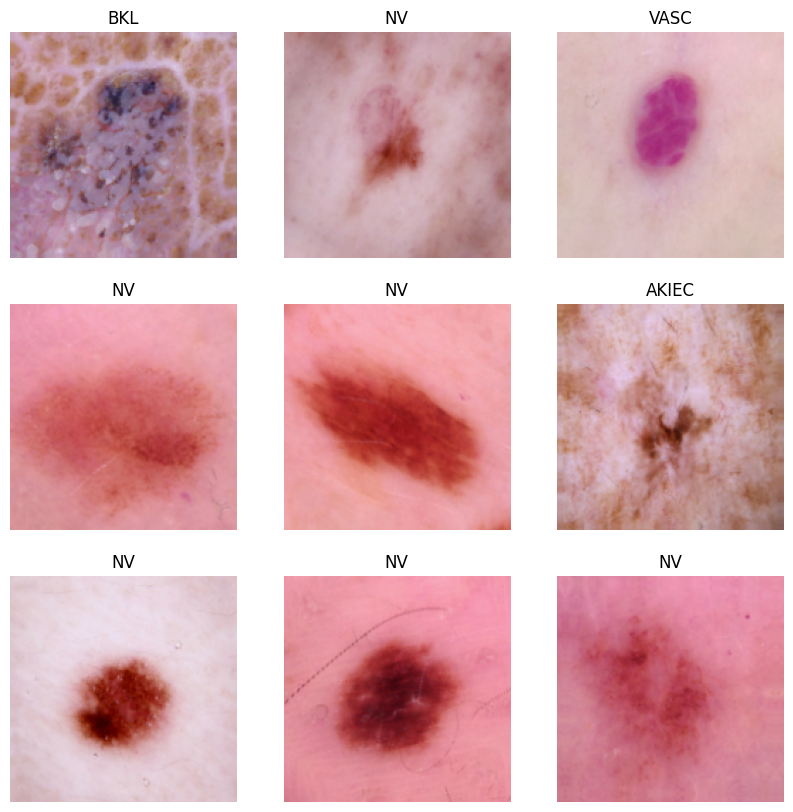

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        plt.title(class_name[int(labels[i].numpy())])
        plt.axis("off")

plt.show()

Quantidade de imagens no conjunto de treino: 7010


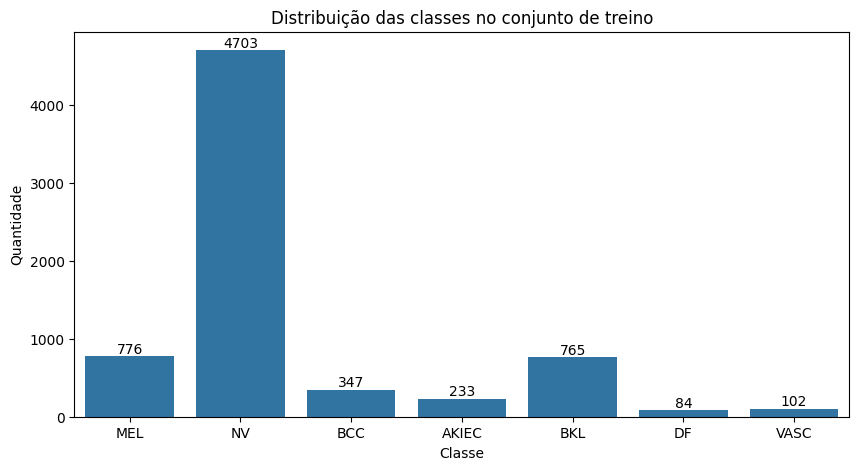

MEL       776.0
NV       4703.0
BCC       347.0
AKIEC     233.0
BKL       765.0
DF         84.0
VASC      102.0
dtype: object


In [11]:
train_label_df = pd.DataFrame(columns=classes)

# A contagem é feita no conjunto de treino original, antes do Data Augmentation.
for image, label in train_ds_raw.as_numpy_iterator():
    label_array = np.zeros((1, len(classes)))
    label_array[0, int(label)] = 1

    batch_df = pd.DataFrame(label_array, columns=classes)
    train_label_df = pd.concat([train_label_df, batch_df], ignore_index=True)

card = len(train_label_df)
print("Quantidade de imagens no conjunto de treino:", card)

label_counts = train_label_df.sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição das classes no conjunto de treino")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

print(label_counts)


In [12]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False

inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = preprocess_input(inputs)
x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(x)

x = Dropout(0.5)(x)

outputs = Dense(len(classes))(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 160, 160)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 160, 160)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 160, 160)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 160, 160,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 160, 160,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 5, 5,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [14]:
y_train_labels = []

for image, label in train_ds_raw.as_numpy_iterator():
    y_train_labels.append(int(label))

y_train_labels = np.array(y_train_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(classes)),
    y=y_train_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_values)
}

print("Pesos por classe:")
for i, weight in class_weights.items():
    print(f"{class_name[i]}: {weight:.4f}")


Pesos por classe:
MEL: 1.2905
NV: 0.2129
BCC: 2.8860
AKIEC: 4.2980
BKL: 1.3091
DF: 11.9218
VASC: 9.8179


In [15]:
early_stopping_phase1 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase1 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

early_stopping_fine_tuning = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_fine_tuning = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

phase1_checkpoint_path = "best_cnn_cw_resnet50_phase1.keras"
fine_tune_checkpoint_path = "best_cnn_cw_resnet50_finetuned.keras"

phase1_checkpoint = keras.callbacks.ModelCheckpoint(
    phase1_checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

fine_tune_checkpoint = keras.callbacks.ModelCheckpoint(
    fine_tune_checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [16]:
# Etapa 1: treinamento apenas da cabeça classificadora.
# A base ResNet50 permanece congelada.

history = model.fit(
    train_ds,
    epochs=200,
    validation_data=val_ds,
    callbacks=[early_stopping_phase1, reduce_lr_phase1, phase1_checkpoint],
    class_weight=class_weights
)


Epoch 1/200
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.1815 - loss: 3.1050
Epoch 1: val_loss improved from None to 1.84070, saving model to best_cnn_cw_resnet50_phase1.keras

Epoch 1: finished saving model to best_cnn_cw_resnet50_phase1.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 91s 400ms/step - accuracy: 0.2591 - loss: 2.6674 - val_accuracy: 0.5073 - val_loss: 1.8407 - learning_rate: 1.0000e-04
Epoch 2/200
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.4279 - loss: 2.0312
Epoch 2: val_loss improved from 1.84070 to 1.71692, saving model to best_cnn_cw_resnet50_phase1.keras

Epoch 2: finished saving model to best_cnn_cw_resnet50_phase1.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 91s 412ms/step - accuracy: 0.4455 - loss: 1.9802 - val_accuracy: 0.5772 - val_loss: 1.7169 - learning_rate: 1.0000e-04
Epoch 3/200
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.4761 - loss: 1.8569
Epoch 3: val_loss did not improve from 1.71692
220/220 ━━━━━━━━━━━━━━━━━━━━ 99s 450ms/step - accur

### FINE-TUNING DA RESNET50

Após treinar a cabeça classificadora, as últimas camadas da ResNet50 são descongeladas para adaptar melhor os filtros ao problema de classificação das lesões.


In [17]:
# Carrega o melhor modelo da primeira etapa antes do fine-tuning.
model = load_model(phase1_checkpoint_path)

base_model = model.get_layer("resnet50")
base_model.trainable = True

# Mantém a maior parte da ResNet50 congelada e libera apenas as últimas camadas.
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Por estabilidade, camadas BatchNormalization da ResNet50 permanecem congeladas no fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping_fine_tuning, reduce_lr_fine_tuning, fine_tune_checkpoint],
    class_weight=class_weights
)


Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.7717 - loss: 0.8469
Epoch 1: val_loss improved from None to 1.24424, saving model to best_cnn_cw_resnet50_finetuned.keras

Epoch 1: finished saving model to best_cnn_cw_resnet50_finetuned.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 172s 767ms/step - accuracy: 0.7635 - loss: 0.8498 - val_accuracy: 0.6858 - val_loss: 1.2442 - learning_rate: 1.0000e-05
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.7790 - loss: 0.8110
Epoch 2: val_loss improved from 1.24424 to 1.18424, saving model to best_cnn_cw_resnet50_finetuned.keras

Epoch 2: finished saving model to best_cnn_cw_resnet50_finetuned.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 172s 780ms/step - accuracy: 0.7739 - loss: 0.8279 - val_accuracy: 0.7064 - val_loss: 1.1842 - learning_rate: 1.0000e-05
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.7845 - loss: 0.7785
Epoch 3: val_loss did not improve from 1.18424
220/220 ━━━━━━━━━━━━━━━━━━━━ 171s 778ms/

In [18]:
# Combina os históricos das duas etapas para gráficos e diagnóstico.
history_all = {}

for key in history.history.keys():
    history_all[key] = history.history[key] + fine_tune_history.history.get(key, [])

# Escolhe o melhor modelo entre a etapa inicial e o fine-tuning com base no menor val_loss.
phase1_model = load_model(phase1_checkpoint_path)
fine_tuned_model = load_model(fine_tune_checkpoint_path)

phase1_val_loss = phase1_model.evaluate(val_ds, verbose=0)[0]
fine_tuned_val_loss = fine_tuned_model.evaluate(val_ds, verbose=0)[0]

if fine_tuned_val_loss <= phase1_val_loss:
    best_model = fine_tuned_model
    best_model_name = "Fine-tuning"
    best_val_loss = fine_tuned_val_loss
else:
    best_model = phase1_model
    best_model_name = "Etapa 1"
    best_val_loss = phase1_val_loss

print(f"Melhor modelo selecionado: {best_model_name}")
print(f"Menor val_loss: {best_val_loss:.4f}")


Melhor modelo selecionado: Fine-tuning
Menor val_loss: 1.1018


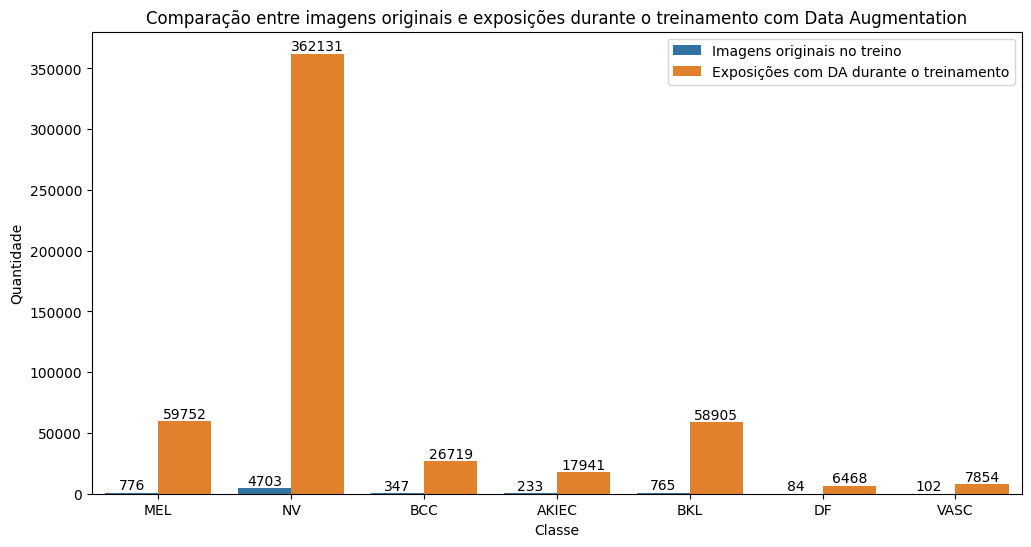

In [19]:
epochs = len(history_all["loss"])

comparison_df = pd.DataFrame({
    "Classe": label_counts.index,
    "Imagens originais no treino": label_counts.values,
    "Exposições com DA durante o treinamento": (label_counts * epochs).values
})

comparison_df_melted = comparison_df.melt(
    id_vars="Classe",
    var_name="Tipo",
    value_name="Quantidade"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=comparison_df_melted,
    x="Classe",
    y="Quantidade",
    hue="Tipo"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Comparação entre imagens originais e exposições durante o treinamento com Data Augmentation")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.legend(title="")
plt.show()


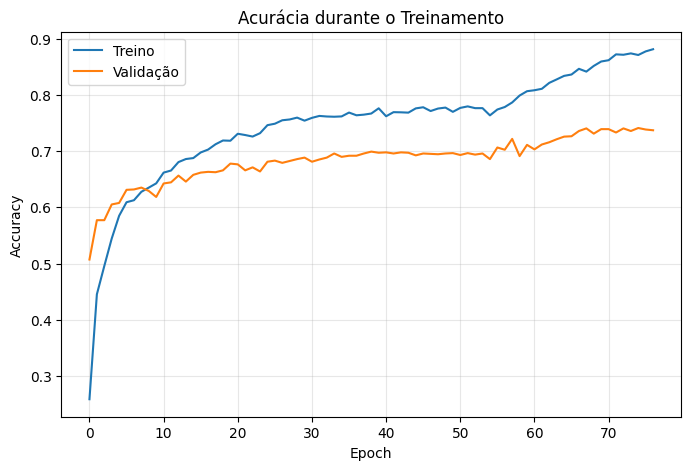

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_all["accuracy"], label="Treino")
plt.plot(history_all["val_accuracy"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Acurácia durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


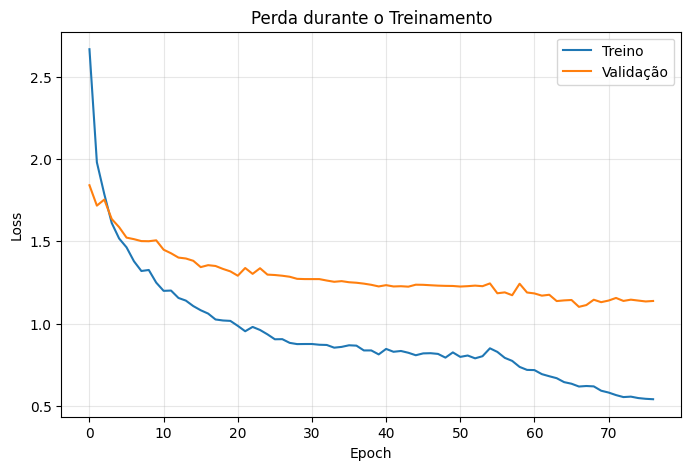

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_all["loss"], label="Treino")
plt.plot(history_all["val_loss"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
probability_model = tf.keras.Sequential([
    best_model,
    layers.Softmax()
])

In [23]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = probability_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

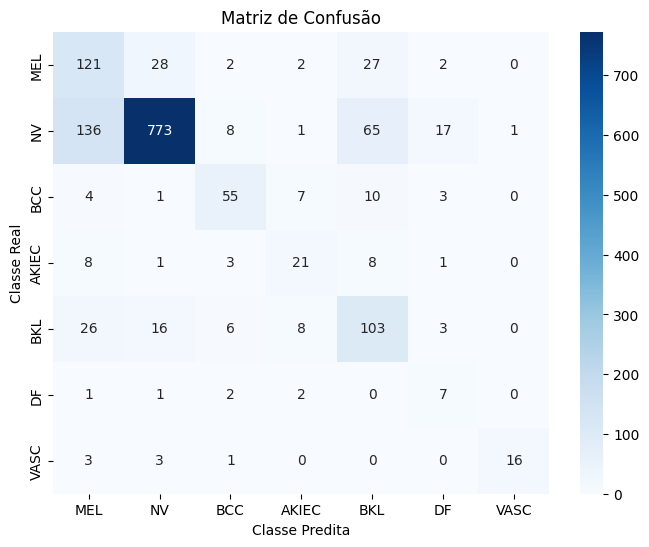

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

In [25]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

         MEL     0.4047    0.6648    0.5031       182
          NV     0.9392    0.7722    0.8476      1001
         BCC     0.7143    0.6875    0.7006        80
       AKIEC     0.5122    0.5000    0.5060        42
         BKL     0.4836    0.6358    0.5493       162
          DF     0.2121    0.5385    0.3043        13
        VASC     0.9412    0.6957    0.8000        23

    accuracy                         0.7292      1503
   macro avg     0.6010    0.6421    0.6016      1503
weighted avg     0.7952    0.7292    0.7509      1503



In [26]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("MÉTRICAS GERAIS DO MODELO")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nMacro Average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_macro:.4f}")
print(f"\nWeighted Average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1-Score: {f1_weighted:.4f}")

MÉTRICAS GERAIS DO MODELO

Accuracy: 0.7292

Macro Average:
  Precision: 0.6010
  Recall: 0.6421
  F1-Score: 0.6016

Weighted Average:
  Precision: 0.7952
  Recall: 0.7292
  F1-Score: 0.7509


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step


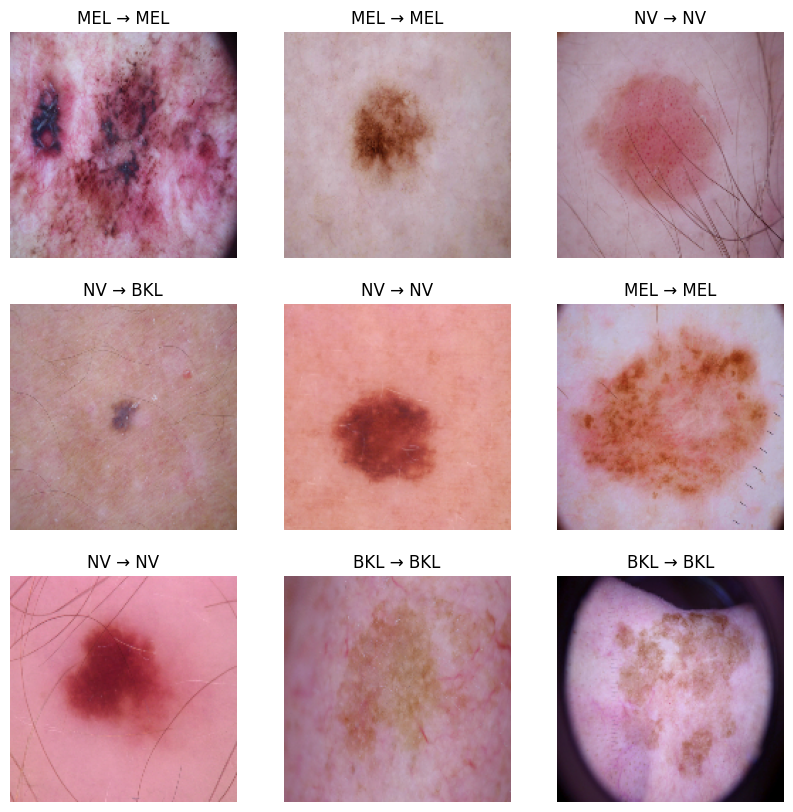

In [27]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    predictions = probability_model.predict(images)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        true_label = class_name[int(labels[i].numpy())]
        pred_label = class_name[int(np.argmax(predictions[i]))]

        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

plt.show()

In [28]:
best_epoch = int(np.argmin(history_all["val_loss"]))

best_train_acc = history_all["accuracy"][best_epoch]
best_val_acc = history_all["val_accuracy"][best_epoch]
best_train_loss = history_all["loss"][best_epoch]
best_val_loss_history = history_all["val_loss"][best_epoch]

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=0)

print("\nDiagnóstico final:")
print(f"Melhor época no histórico: {best_epoch + 1}")
print(f"Train accuracy na melhor época: {best_train_acc:.4f}")
print(f"Val accuracy na melhor época: {best_val_acc:.4f}")
print(f"Train loss na melhor época: {best_train_loss:.4f}")
print(f"Val loss na melhor época: {best_val_loss_history:.4f}")
print(f"Modelo final selecionado: {best_model_name}")
print(f"Test accuracy do melhor modelo: {test_accuracy:.4f}")
print(f"Test loss do melhor modelo: {test_loss:.4f}")



Diagnóstico final:
Melhor época no histórico: 67
Train accuracy na melhor época: 0.8462
Val accuracy na melhor época: 0.7357
Train loss na melhor época: 0.6176
Val loss na melhor época: 1.1018
Modelo final selecionado: Fine-tuning
Test accuracy do melhor modelo: 0.7292
Test loss do melhor modelo: 1.1159
